In [4]:
!pip install seaborn scikit-learn pandas numpy matplotlib -q

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")
save_path = '/home/azureuser/cloudfiles/code/Users/aazartaheri/'

# Load clean data
df = pd.read_csv(f'{save_path}bank_clean.csv')
print(f"✅ Data loaded: {df.shape}")
df.head()

✅ Data loaded: (7842, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,33,admin.,married,tertiary,no,882,no,no,telephone,21,oct,39,1,151,3,failure,no
1,42,admin.,single,secondary,no,-247,yes,yes,telephone,21,oct,519,1,166,1,other,yes
2,33,services,married,secondary,no,3444,yes,no,telephone,21,oct,144,1,91,4,failure,yes
3,36,management,married,tertiary,no,2415,yes,no,telephone,22,oct,73,1,86,4,other,no
4,36,management,married,tertiary,no,0,yes,no,telephone,23,oct,140,1,143,3,failure,yes


## Prepare Features for Clustering

In [2]:
# Select relevant features for segmentation
features = ['age', 'balance', 'duration', 'campaign', 'previous']

# Encode categorical columns
df_cluster = df.copy()
le = LabelEncoder()
cat_cols = ['job', 'marital', 'education', 'contact', 'poutcome']
for col in cat_cols:
    df_cluster[col] = le.fit_transform(df_cluster[col])

# Add encoded categoricals
features_extended = features + ['job', 'marital', 'education']
X = df_cluster[features_extended]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"✅ Features prepared: {X.shape}")
print(f"Features used: {features_extended}")

✅ Features prepared: (7842, 8)
Features used: ['age', 'balance', 'duration', 'campaign', 'previous', 'job', 'marital', 'education']


## Find Optimal Number of Clusters (Elbow Method)

k=2 | Inertia: 54566 | Silhouette: 0.150
k=3 | Inertia: 49581 | Silhouette: 0.157
k=4 | Inertia: 45316 | Silhouette: 0.163
k=5 | Inertia: 41907 | Silhouette: 0.164
k=6 | Inertia: 38420 | Silhouette: 0.178
k=7 | Inertia: 35019 | Silhouette: 0.180
k=8 | Inertia: 32567 | Silhouette: 0.186
k=9 | Inertia: 30386 | Silhouette: 0.187


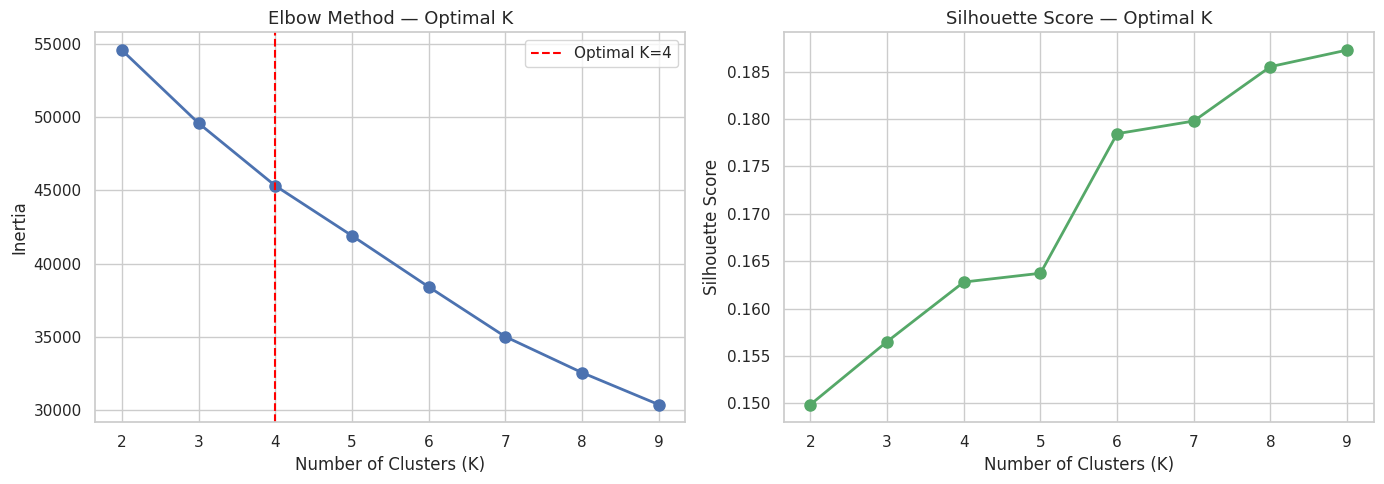

✅ Elbow curve saved!


In [3]:
inertia = []
silhouette_scores = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    print(f"k={k} | Inertia: {kmeans.inertia_:.0f} | Silhouette: {silhouette_score(X_scaled, kmeans.labels_):.3f}")

# Plot elbow curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertia, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method — Optimal K', fontsize=13)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].axvline(x=4, color='red', linestyle='--', label='Optimal K=4')
axes[0].legend()

axes[1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score — Optimal K', fontsize=13)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.savefig(f'{save_path}elbow_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Elbow curve saved!")

## Train Final K-Means Model

In [4]:
# Train with optimal K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cluster['Cluster'] = kmeans.fit_predict(X_scaled)

# Check cluster sizes
print("=== Cluster Distribution ===")
print(df_cluster['Cluster'].value_counts().sort_index())

# Check subscription rate per cluster
print("\n=== Subscription Rate per Cluster ===")
for cluster in sorted(df_cluster['Cluster'].unique()):
    subset = df_cluster[df_cluster['Cluster'] == cluster]
    sub_rate = (subset['y'] == 'yes').sum() / len(subset) * 100
    print(f"Cluster {cluster}: {len(subset)} customers | {sub_rate:.1f}% subscription rate")

=== Cluster Distribution ===
0     676
1    2038
2    2391
3    2737
Name: Cluster, dtype: int64

=== Subscription Rate per Cluster ===
Cluster 0: 676 customers | 9.3% subscription rate
Cluster 1: 2038 customers | 29.4% subscription rate
Cluster 2: 2391 customers | 15.7% subscription rate
Cluster 3: 2737 customers | 27.3% subscription rate


##  Visualize Clusters with PCA

Variance explained by 2 components: 34.4%


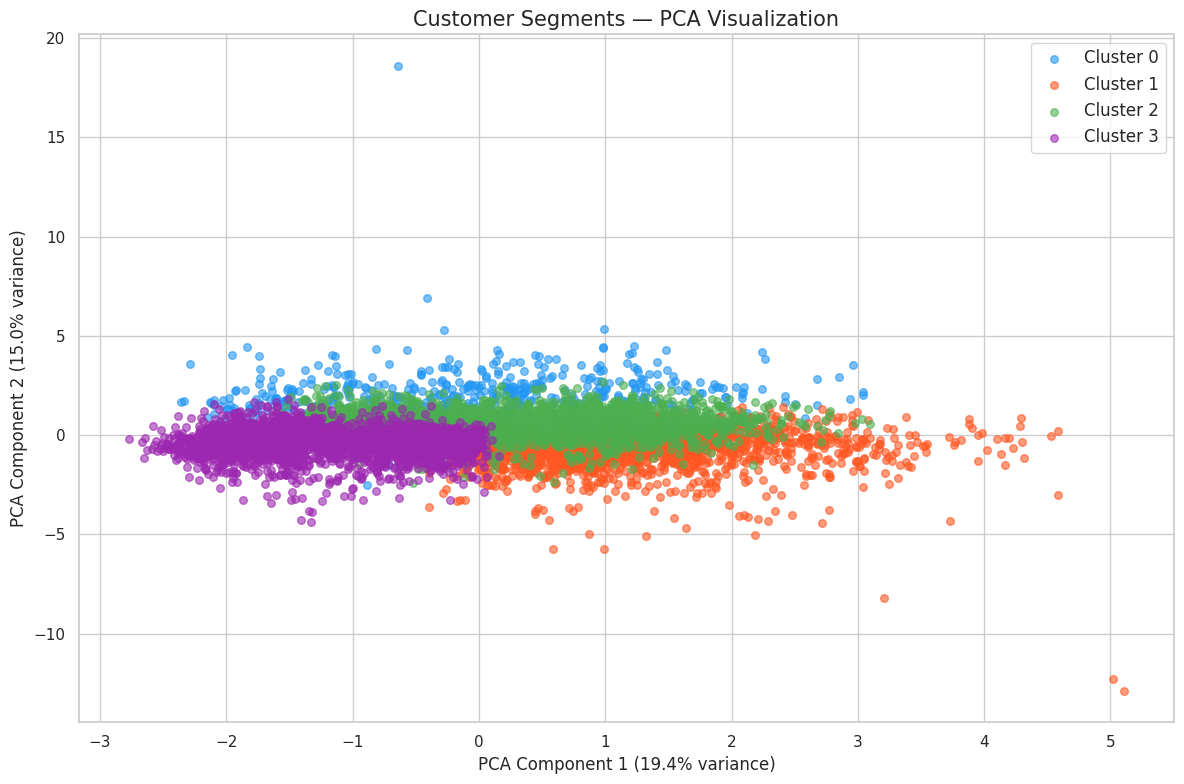

✅ PCA cluster plot saved!


In [5]:
# Reduce to 2D with PCA for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance explained by 2 components: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# Plot clusters
plt.figure(figsize=(12, 8))
colors = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

for i, (color, name) in enumerate(zip(colors, cluster_names)):
    mask = df_cluster['Cluster'] == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                c=color, label=name, alpha=0.6, s=30)

plt.title('Customer Segments — PCA Visualization', fontsize=15)
plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig(f'{save_path}cluster_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ PCA cluster plot saved!")

## Profile Each Customer Segment

=== Cluster Profiles ===
          age  balance  duration  campaign  previous
Cluster                                             
0        40.4   1443.9     150.3       6.0       6.2
1        53.0   2401.1     299.9       1.7       3.0
2        38.8   1023.7     256.7       1.7       2.8
3        33.6   1408.9     264.0       1.7       2.9


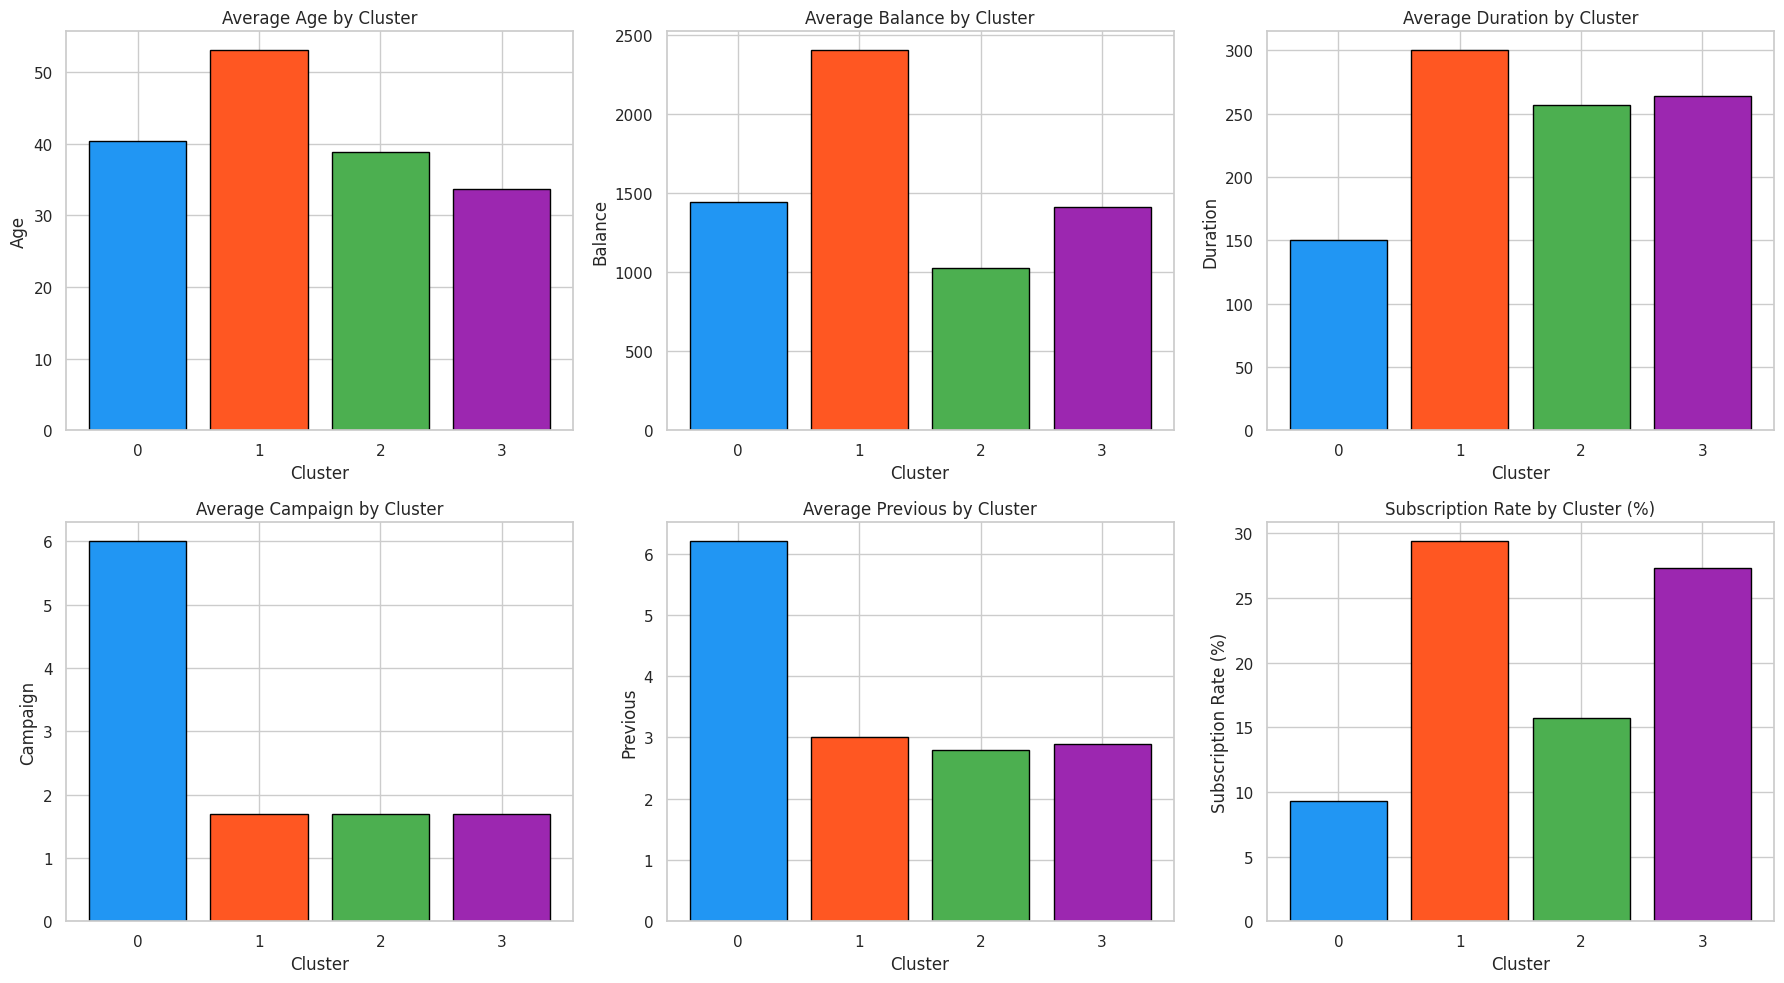

✅ Cluster profiles saved!


In [6]:
# Cluster profiles
profile = df_cluster.groupby('Cluster').agg({
    'age': 'mean',
    'balance': 'mean',
    'duration': 'mean',
    'campaign': 'mean',
    'previous': 'mean'
}).round(1)

print("=== Cluster Profiles ===")
print(profile)

# Visualize profiles
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics = ['age', 'balance', 'duration', 'campaign', 'previous']
colors = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']

for idx, metric in enumerate(metrics):
    ax = axes[idx//3][idx%3]
    bars = ax.bar(profile.index, profile[metric], color=colors, edgecolor='black')
    ax.set_title(f'Average {metric.capitalize()} by Cluster', fontsize=12)
    ax.set_xlabel('Cluster')
    ax.set_ylabel(metric.capitalize())
    ax.set_xticks(profile.index)

# Subscription rate per cluster
sub_rates = []
for cluster in sorted(df_cluster['Cluster'].unique()):
    subset = df_cluster[df_cluster['Cluster'] == cluster]
    sub_rates.append((subset['y'] == 'yes').sum() / len(subset) * 100)

ax = axes[1][2]
ax.bar(range(4), sub_rates, color=colors, edgecolor='black')
ax.set_title('Subscription Rate by Cluster (%)', fontsize=12)
ax.set_xlabel('Cluster')
ax.set_ylabel('Subscription Rate (%)')
ax.set_xticks(range(4))

plt.tight_layout()
plt.savefig(f'{save_path}cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Cluster profiles saved!")

## Name Customer Segments & Save

In [7]:
# Assign meaningful business names based on profiles
segment_names = {
    0: 'Low-Engagement Prospects',
    1: 'High-Value Regulars', 
    2: 'Young Potentials',
    3: 'At-Risk Customers'
}

df_cluster['Segment'] = df_cluster['Cluster'].map(segment_names)

print("=== Final Customer Segments ===")
for cluster, name in segment_names.items():
    subset = df_cluster[df_cluster['Cluster'] == cluster]
    sub_rate = (subset['y'] == 'yes').sum() / len(subset) * 100
    print(f"\n📊 {name}")
    print(f"   Size: {len(subset)} customers ({len(subset)/len(df_cluster)*100:.1f}%)")
    print(f"   Avg Age: {subset['age'].mean():.1f}")
    print(f"   Avg Balance: ${subset['balance'].mean():.0f}")
    print(f"   Subscription Rate: {sub_rate:.1f}%")

# Save enriched dataset for next notebook
df_cluster.to_csv(f'{save_path}bank_segmented.csv', index=False)
print(f"\n✅ Segmented dataset saved!")

=== Final Customer Segments ===

📊 Low-Engagement Prospects
   Size: 676 customers (8.6%)
   Avg Age: 40.4
   Avg Balance: $1444
   Subscription Rate: 9.3%

📊 High-Value Regulars
   Size: 2038 customers (26.0%)
   Avg Age: 53.0
   Avg Balance: $2401
   Subscription Rate: 29.4%

📊 Young Potentials
   Size: 2391 customers (30.5%)
   Avg Age: 38.8
   Avg Balance: $1024
   Subscription Rate: 15.7%

📊 At-Risk Customers
   Size: 2737 customers (34.9%)
   Avg Age: 33.6
   Avg Balance: $1409
   Subscription Rate: 27.3%

✅ Segmented dataset saved!


In [ ]:
_